# Oja Verification

Quick verification experiments that Oja's rule works as intended

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from experimental_setups.hebbian_model import OjaOneHotModel, OjaEmbedModel, OjaDecayModel
import data
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 1. One-Hot input

Oja's rule on one-hot input encodings

In [ ]:
oja_test = OjaOneHotModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = torch.Tensor([
    [1.0, 0.0],
    [0.0, 1.0],
]).repeat(95,1)

statistics = oja_test.learn_oja(train_x, epochs=100)

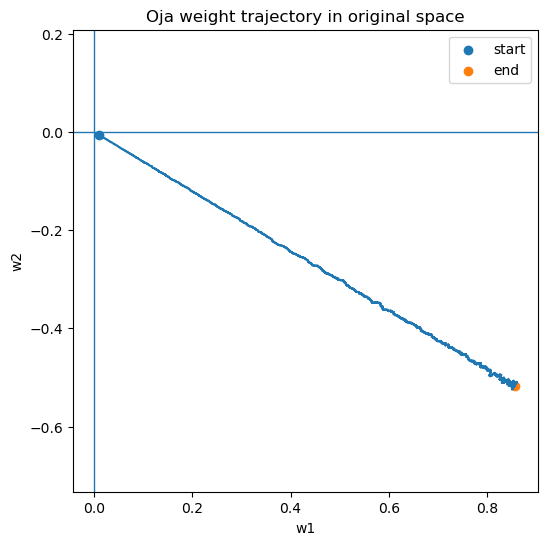

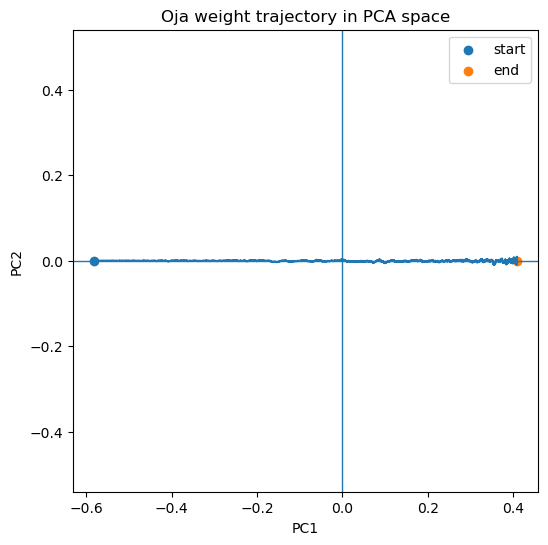

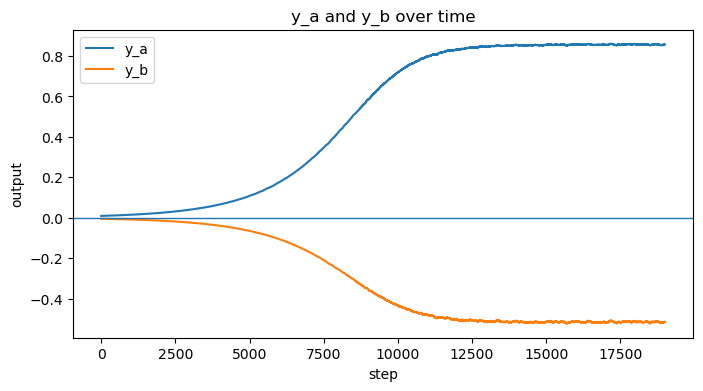

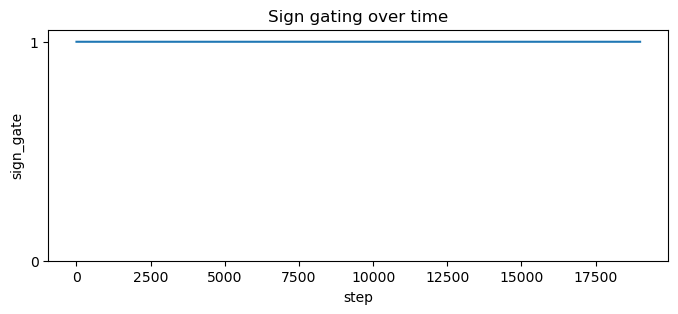

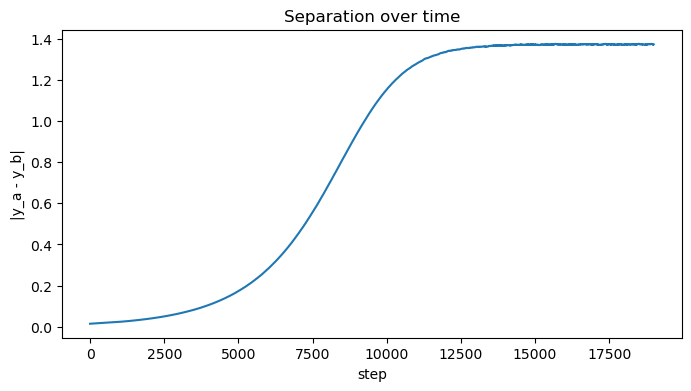

In [11]:
df = statistics.copy()

# ----------------------------
# 1. PCA of the weight trajectory
# ----------------------------
W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
W_pca = pca.fit_transform(W)

df["pc1"] = W_pca[:, 0]
df["pc2"] = W_pca[:, 1]

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

In [ ]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))

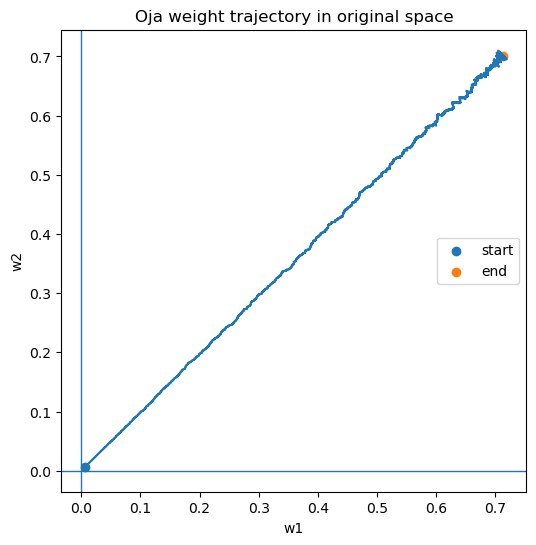

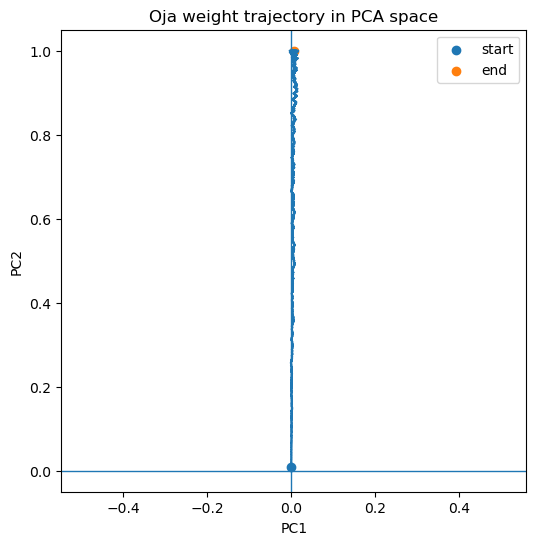

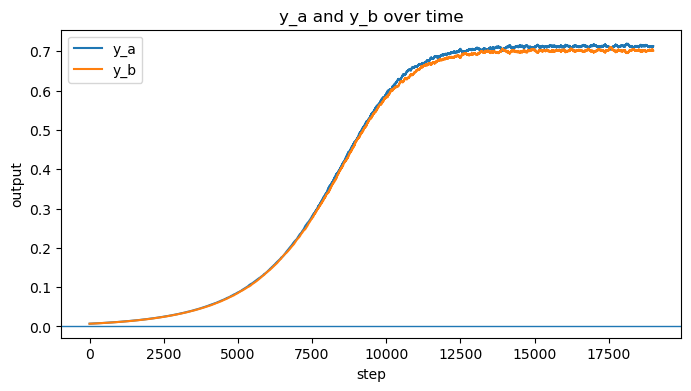

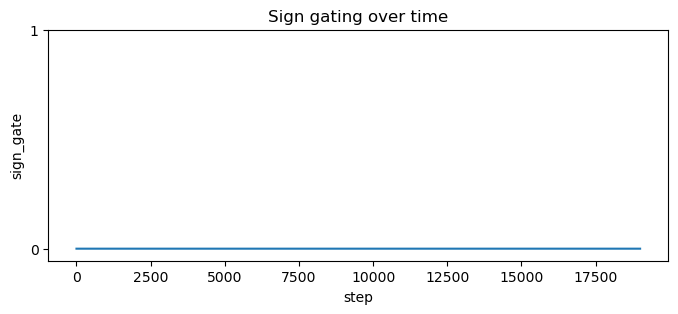

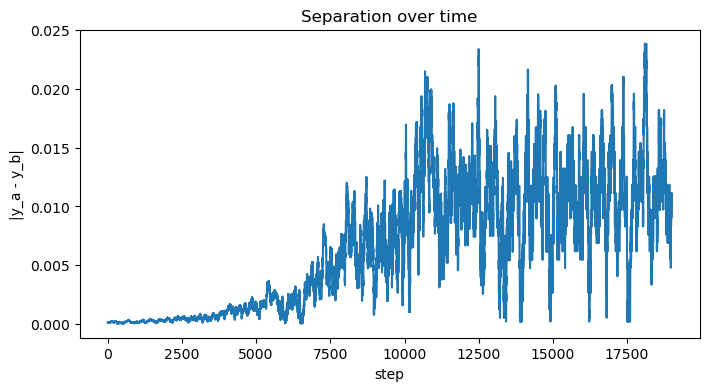

In [17]:
# oja_test = OjaOneHotModel(lr=1e-3)

# device = torch.device("cpu")

# oja_test.to(device)

# train_x = torch.Tensor([
#     [1.0, 0.0],
#     [0.0, 1.0],
# ]).repeat(95,1)

# statistics = oja_test.learn_oja(train_x, epochs=100)
df = statistics.copy()

# # ----------------------------
# # 1. PCA of the weight trajectory
# # ----------------------------
# W = df[["w1", "w2"]].to_numpy()

# pca = PCA(n_components=2)
# W_pca = pca.fit_transform(W)

v1 = np.array([1, -1]) / np.sqrt(2)   # PC1
v2 = np.array([1,  1]) / np.sqrt(2)   # PC2

W = df[["w1", "w2"]].to_numpy()

df["pc1"] = W @ v1
df["pc2"] = W @ v2

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

Center the inputs

In [4]:
oja_test = OjaOneHotModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = torch.Tensor([
    [.5, -.5],
    [-.5, .5],
]).repeat(95,1)

statistics = oja_test.learn_oja(train_x, epochs=100)

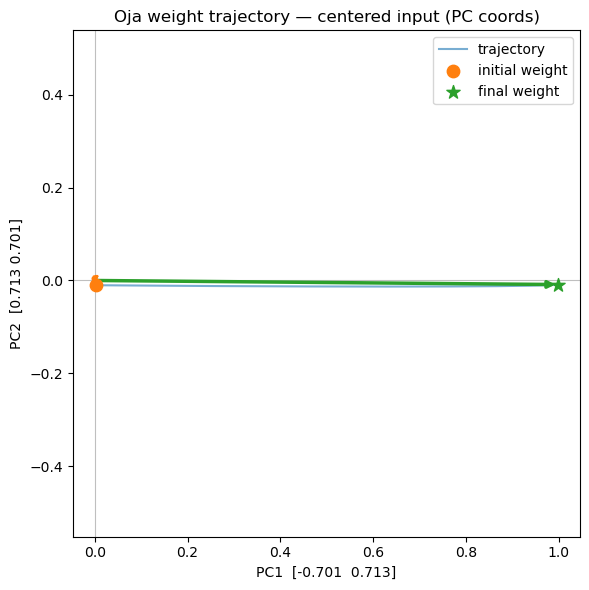

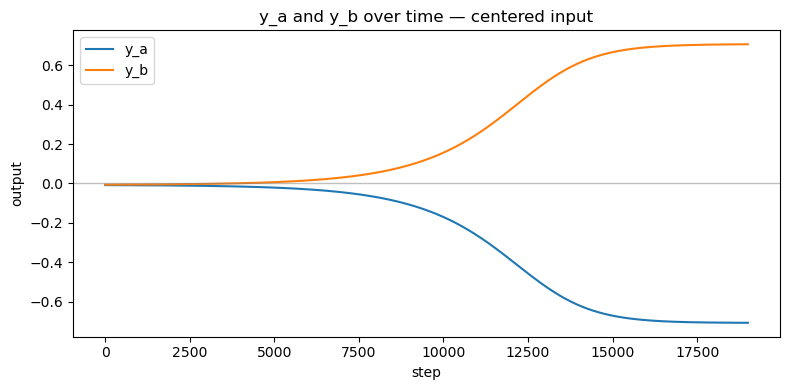

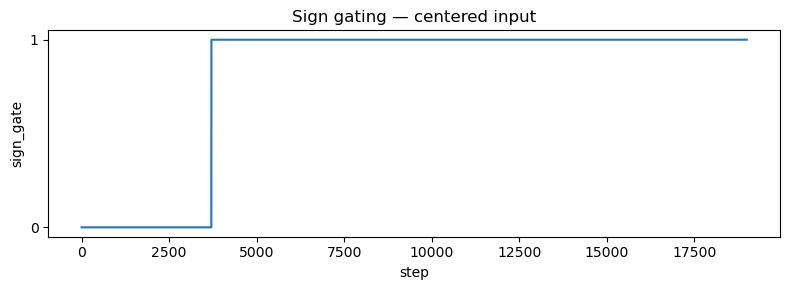

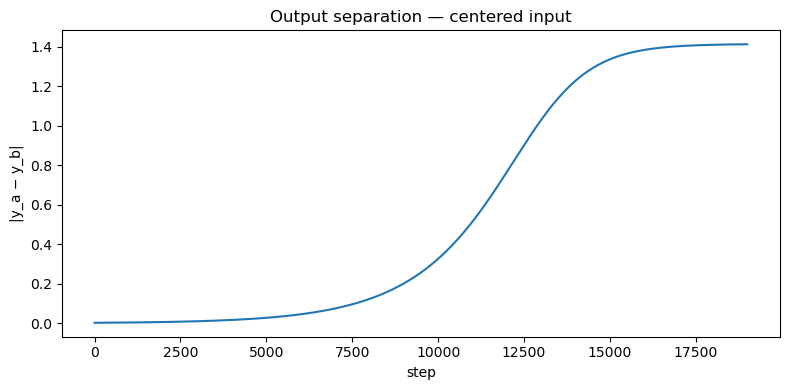

In [5]:
import os
os.makedirs("images/oja-pc-conv", exist_ok=True)

df = statistics.copy()

W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
pca.fit(W)
v1 = pca.components_[0]
v2 = pca.components_[1]

df["pc1"] = W @ v1
df["pc2"] = W @ v2

w_init = W[0]
w_final = W[-1]

# ----------------------------
# Weight trajectory in PC space
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(df["pc1"], df["pc2"], linewidth=1.5, color="tab:blue", alpha=0.6, label="trajectory", zorder=1)

# Initial weight — dashed arrow from origin, distinct color
ax.annotate(
    "", xy=(df["pc1"].iloc[0], df["pc2"].iloc[0]), xytext=(0, 0),
    arrowprops=dict(arrowstyle="-|>", color="tab:orange", lw=2, linestyle="dashed"),
    zorder=3,
)
ax.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0],
           s=80, color="tab:orange", zorder=4, label="initial weight", marker="o")

# Final weight — solid arrow from origin
ax.annotate(
    "", xy=(df["pc1"].iloc[-1], df["pc2"].iloc[-1]), xytext=(0, 0),
    arrowprops=dict(arrowstyle="-|>", color="tab:green", lw=2.5),
    zorder=3,
)
ax.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1],
           s=100, color="tab:green", zorder=4, label="final weight", marker="*")

ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.set_xlabel(f"PC1  {np.round(v1, 3)}")
ax.set_ylabel(f"PC2  {np.round(v2, 3)}")
ax.set_title("Oja weight trajectory — centered input (PC coords)")
ax.legend()
ax.axis("equal")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_weight_trajectory.png", dpi=150)
plt.show()

# ----------------------------
# y_a and y_b over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["step"], df["y_a"], label="y_a")
ax.plot(df["step"], df["y_b"], label="y_b")
ax.axhline(0, linewidth=1, color="gray", alpha=0.5)
ax.set_xlabel("step")
ax.set_ylabel("output")
ax.set_title("y_a and y_b over time — centered input")
ax.legend()
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_outputs.png", dpi=150)
plt.show()

# ----------------------------
# Sign gating over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
ax.set_xlabel("step")
ax.set_ylabel("sign_gate")
ax.set_yticks([0, 1])
ax.set_title("Sign gating — centered input")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_sign_gate.png", dpi=150)
plt.show()

# ----------------------------
# Separation over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["step"], df["separation"], linewidth=1.5)
ax.set_xlabel("step")
ax.set_ylabel("|y_a − y_b|")
ax.set_title("Output separation — centered input")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_separation.png", dpi=150)
plt.show()

In [20]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))

0.9999999912399137


### Centered input over 50 random seeds

Aggregate 50 centered-input runs to see where Oja's rule converges in weight space and how the target and orthogonal components evolve across random initializations.


In [6]:
num_runs = 50
centered_epochs = 100
centered_train_x = torch.tensor([
    [0.5, -0.5],
    [-0.5, 0.5],
], device=device).repeat(95, 1)

target_axis = np.array([1.0, -1.0]) / np.sqrt(2.0)
orth_axis = np.array([1.0, 1.0]) / np.sqrt(2.0)

centered_runs = []
for seed in range(num_runs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    run_model = OjaOneHotModel(lr=1e-3).to(device)
    run_df = run_model.learn_oja(centered_train_x, epochs=centered_epochs)
    run_df["run"] = seed

    weights = run_df[["w1", "w2"]].to_numpy()
    run_df["target_component"] = weights @ target_axis
    run_df["orthogonal_component"] = weights @ orth_axis
    run_df["weight_norm"] = np.linalg.norm(weights, axis=1)

    centered_runs.append(run_df)

centered_runs = pd.concat(centered_runs, ignore_index=True)

centered_summary = (
    centered_runs.groupby("step")
    .agg(
        y_a_mean=("y_a", "mean"),
        y_a_std=("y_a", "std"),
        y_b_mean=("y_b", "mean"),
        y_b_std=("y_b", "std"),
        sign_gate_mean=("sign_gate", "mean"),
        sign_gate_std=("sign_gate", "std"),
        separation_mean=("separation", "mean"),
        separation_std=("separation", "std"),
        target_component_mean=("target_component", "mean"),
        target_component_std=("target_component", "std"),
        orthogonal_component_mean=("orthogonal_component", "mean"),
        orthogonal_component_std=("orthogonal_component", "std"),
        weight_norm_mean=("weight_norm", "mean"),
        weight_norm_std=("weight_norm", "std"),
    )
    .fillna(0.0)
    .reset_index()
)

centered_final = centered_runs.groupby("run", as_index=False).tail(1).copy()
final_weights = centered_final[["w1", "w2"]].to_numpy()
final_weight_norm = np.linalg.norm(final_weights, axis=1)
centered_final["target_alignment"] = np.abs(final_weights @ target_axis) / np.clip(final_weight_norm, 1e-12, None)

centered_final[["run", "w1", "w2", "target_component", "orthogonal_component", "target_alignment"]].head()


,run,w1,w2,target_component,orthogonal_component,target_alignment
18999,0,-0.702876,0.700993,-0.992685,-0.001332,0.999999
37999,1,-0.706994,0.707038,-0.999872,0.000031,1.000000
56999,2,0.706768,-0.706697,0.999471,0.000051,1.000000
75999,3,0.706819,-0.707099,0.999790,-0.000198,1.000000
94999,4,-0.706714,0.706091,-0.999004,-0.000441,1.000000


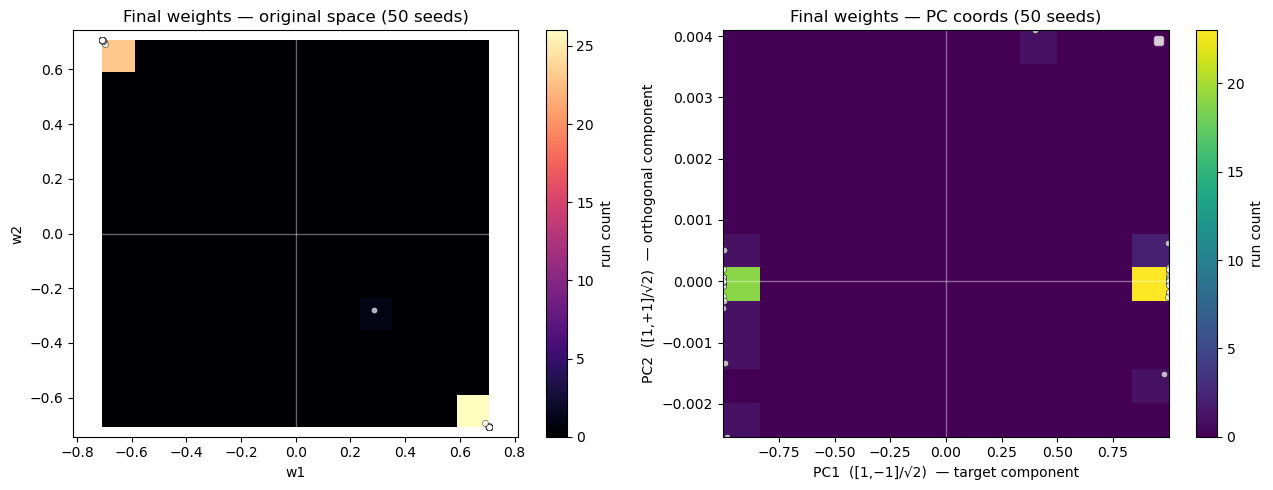

,w1,w2,target_alignment
count,50.000000,50.000000,50.000000
mean,0.048187,-0.048203,0.999999
std,0.705760,0.705614,0.000007
min,-0.707110,-0.707115,0.999948
25%,-0.706992,-0.707050,1.000000
50%,0.698266,-0.699519,1.000000
75%,0.707072,0.707011,1.000000
max,0.707122,0.707100,1.000000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: final weights in original space ---
hist_weights = axes[0].hist2d(
    centered_final["w1"],
    centered_final["w2"],
    bins=12,
    cmap="magma",
)
axes[0].scatter(centered_final["w1"], centered_final["w2"],
                s=20, c="white", edgecolors="black", linewidth=0.4, alpha=0.7)
axes[0].axhline(0, color="white", linewidth=1, alpha=0.4)
axes[0].axvline(0, color="white", linewidth=1, alpha=0.4)
axes[0].set_xlabel("w1")
axes[0].set_ylabel("w2")
axes[0].set_title("Final weights — original space (50 seeds)")
axes[0].axis("equal")
plt.colorbar(hist_weights[3], ax=axes[0], label="run count")

# --- Right: final weights in PC coords (target axis = PC1 = [1,-1]/√2) ---
hist_basis = axes[1].hist2d(
    centered_final["target_component"],
    centered_final["orthogonal_component"],
    bins=12,
    cmap="viridis",
)
axes[1].scatter(
    centered_final["target_component"],
    centered_final["orthogonal_component"],
    s=20, c="white", edgecolors="black", linewidth=0.4, alpha=0.7,
)
axes[1].axhline(0, color="white", linewidth=1, alpha=0.4)
axes[1].axvline(0, color="white", linewidth=1, alpha=0.4)
axes[1].set_xlabel("PC1  ([1,−1]/√2)  — target component")
axes[1].set_ylabel("PC2  ([1,+1]/√2)  — orthogonal component")
axes[1].set_title("Final weights — PC coords (50 seeds)")
plt.colorbar(hist_basis[3], ax=axes[1], label="run count")
handles, labels = axes[1].get_legend_handles_labels()
# deduplicate legend entries
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
axes[1].legend(seen.values(), seen.keys(), fontsize=8)

plt.tight_layout()
plt.savefig("images/oja-pc-conv/final_weights_50seeds.png", dpi=150)
plt.show()

centered_final[["w1", "w2", "target_alignment"]].describe()


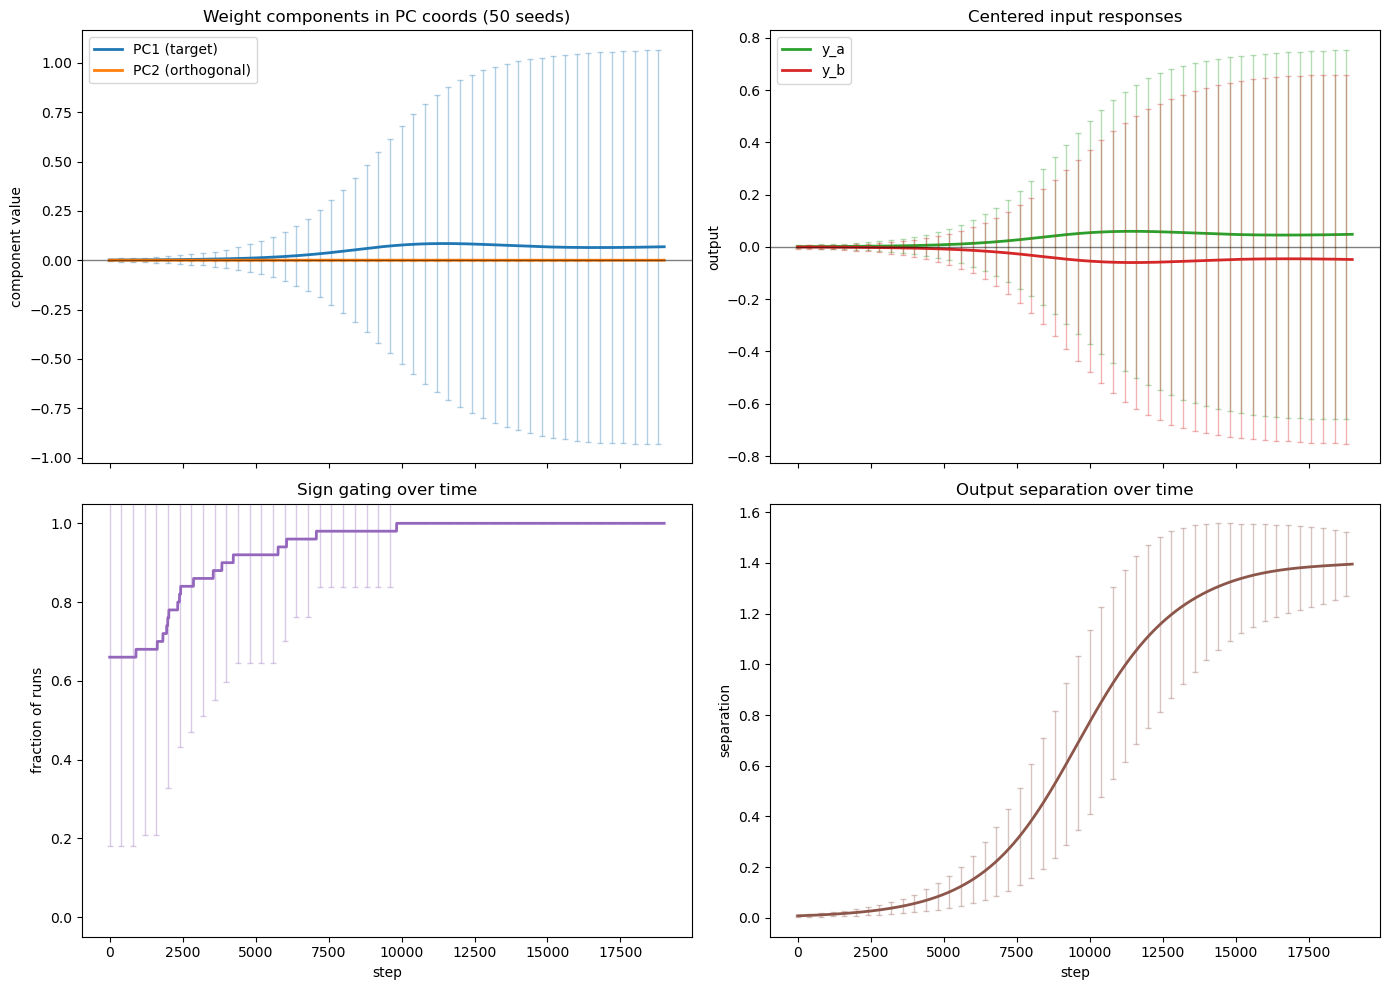

In [8]:
def add_errorbars(ax, summary_df, mean_col, std_col, label, color, stride=400):
    ax.plot(summary_df["step"], summary_df[mean_col], label=label, color=color, linewidth=2)
    sample = summary_df.iloc[::stride]
    ax.errorbar(
        sample["step"],
        sample[mean_col],
        yerr=sample[std_col],
        fmt="none",
        ecolor=color,
        elinewidth=1,
        alpha=0.35,
        capsize=2,
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

add_errorbars(axes[0, 0], centered_summary, "target_component_mean", "target_component_std", "PC1 (target)", "tab:blue")
add_errorbars(axes[0, 0], centered_summary, "orthogonal_component_mean", "orthogonal_component_std", "PC2 (orthogonal)", "tab:orange")
axes[0, 0].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0, 0].set_ylabel("component value")
axes[0, 0].set_title("Weight components in PC coords (50 seeds)")
axes[0, 0].legend()

add_errorbars(axes[0, 1], centered_summary, "y_a_mean", "y_a_std", "y_a", "tab:green")
add_errorbars(axes[0, 1], centered_summary, "y_b_mean", "y_b_std", "y_b", "tab:red")
axes[0, 1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0, 1].set_ylabel("output")
axes[0, 1].set_title("Centered input responses")
axes[0, 1].legend()

add_errorbars(axes[1, 0], centered_summary, "sign_gate_mean", "sign_gate_std", "sign_gate", "tab:purple")
axes[1, 0].set_ylim(-0.05, 1.05)
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("fraction of runs")
axes[1, 0].set_title("Sign gating over time")

add_errorbars(axes[1, 1], centered_summary, "separation_mean", "separation_std", "|y_a - y_b|", "tab:brown")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("separation")
axes[1, 1].set_title("Output separation over time")

plt.tight_layout()
plt.savefig("images/oja-pc-conv/summary_timeseries_50seeds.png", dpi=150)
plt.show()


## 2. Embedding layer

We now examine the behaviour with embedding layer added.

In [1]:
oja_test = OjaEmbedModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = data.make_behavioral_experiment_training_data(distractor_strength=.975)[0]

# filter data to always contain category context
train_x = train_x[1][:20*19]
statistics = oja_test.learn_oja(train_x)

NameError: name 'OjaEmbedModel' is not defined

In [ ]:
df = statistics.copy()

# ----------------------------
# 1. PCA of the weight trajectory
# ----------------------------
W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
W_pca = pca.fit_transform(W)

df["pc1"] = W_pca[:, 0]
df["pc2"] = W_pca[:, 1]

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

In [ ]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))